In [ ]:
!pip install torch torchvision matplotlib pillow numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os

# Create folders
os.makedirs("shapes/circle", exist_ok=True)
os.makedirs("shapes/square", exist_ok=True)

img_size = 64

# Generate circle images
for i in range(100):

    img = Image.new("L", (img_size, img_size), color=0)

    draw = ImageDraw.Draw(img)

    draw.ellipse((16,16,48,48), fill=255)

    img.save(f"shapes/circle/circle_{i}.png")

# Generate square images
for i in range(100):

    img = Image.new("L", (img_size, img_size), color=0)

    draw = ImageDraw.Draw(img)

    draw.rectangle((16,16,48,48), fill=255)

    img.save(f"shapes/square/square_{i}.png")

print("Shape Dataset Created Successfully!")

Shape Dataset Created Successfully!


In [ ]:
import os

print(os.listdir("shapes"))

['circle', 'square']


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

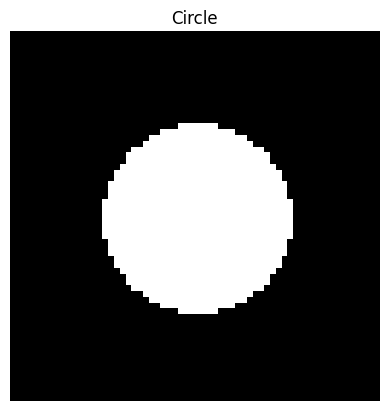

In [ ]:
from PIL import Image

img = Image.open("shapes/circle/circle_0.png")

plt.imshow(img, cmap="gray")

plt.title("Circle")

plt.axis("off")

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

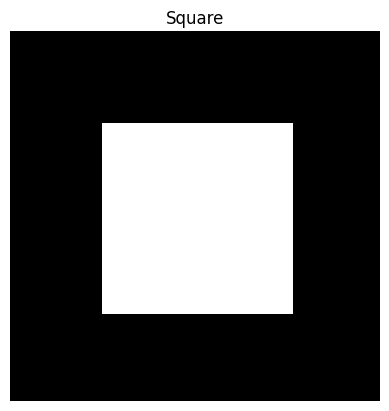

In [ ]:
img = Image.open("shapes/square/square_0.png")

plt.imshow(img, cmap="gray")

plt.title("Square")

plt.axis("off")

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
dataset = datasets.ImageFolder(
    "shapes",
    transform=transform
)

# Create dataloader
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Classes:", dataset.classes)

print("Total Images:", len(dataset))

Classes: ['circle', 'square']
Total Images: 200


In [ ]:
import torch
import torch.nn as nn

latent_dim = 100
num_classes = 2

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.label_emb = nn.Embedding(
            num_classes,
            num_classes
        )

        self.model = nn.Sequential(

            nn.Linear(latent_dim + num_classes, 128),

            nn.ReLU(),

            nn.Linear(128, 256),

            nn.ReLU(),

            nn.Linear(256, 64*64),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        label_input = self.label_emb(labels)

        x = torch.cat(
            (noise, label_input),
            -1
        )

        img = self.model(x)

        img = img.view(
            img.size(0),
            1,
            64,
            64
        )

        return img

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.label_emb = nn.Embedding(
            num_classes,
            num_classes
        )

        self.model = nn.Sequential(

            nn.Linear(64*64 + num_classes, 256),

            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),

            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),

            nn.Sigmoid()
        )

    def forward(self, img, labels):

        img = img.view(img.size(0), -1)

        label_input = self.label_emb(labels)

        x = torch.cat(
            (img, label_input),
            -1
        )

        validity = self.model(x)

        return validity

In [ ]:
generator = Generator()

discriminator = Discriminator()

print(generator)

print(discriminator)

Generator(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4096, bias=True)
    (5): Tanh()
  )
)
Discriminator(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=4098, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)

print("Loss and Optimizers Ready!")

Loss and Optimizers Ready!


In [ ]:
transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=1),

    transforms.Resize((64,64)),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.ImageFolder(
    "shapes",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Dataset Reloaded Successfully!")

Dataset Reloaded Successfully!


In [ ]:
for epoch in range(10):

    for imgs, labels in loader:

        batch_size = imgs.size(0)

        # Real and fake labels
        real = torch.ones(batch_size, 1)

        fake = torch.zeros(batch_size, 1)

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            latent_dim
        )

        gen_imgs = generator(
            noise,
            labels
        )

        validity = discriminator(
            gen_imgs,
            labels
        )

        g_loss = criterion(
            validity,
            real
        )

        g_loss.backward()

        optimizer_G.step()

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        real_loss = criterion(
            discriminator(imgs, labels),
            real
        )

        fake_loss = criterion(
            discriminator(
                gen_imgs.detach(),
                labels
            ),
            fake
        )

        d_loss = (
            real_loss + fake_loss
        ) / 2

        d_loss.backward()

        optimizer_D.step()

    print(
        f"Epoch {epoch+1} | "
        f"D Loss: {d_loss.item()} | "
        f"G Loss: {g_loss.item()}"
    )

Epoch 1 | D Loss: 0.36530983448028564 | G Loss: 0.6588854193687439
Epoch 2 | D Loss: 0.3296744227409363 | G Loss: 0.7283929586410522
Epoch 3 | D Loss: 0.2287358045578003 | G Loss: 1.0032219886779785
Epoch 4 | D Loss: 0.13464419543743134 | G Loss: 1.4656492471694946
Epoch 5 | D Loss: 0.20476600527763367 | G Loss: 1.1382601261138916
Epoch 6 | D Loss: 0.49485328793525696 | G Loss: 0.49146711826324463
Epoch 7 | D Loss: 0.3319741189479828 | G Loss: 0.7827713489532471
Epoch 8 | D Loss: 0.12715424597263336 | G Loss: 1.559810996055603
Epoch 9 | D Loss: 0.09209702908992767 | G Loss: 1.8503992557525635
Epoch 10 | D Loss: 0.16036802530288696 | G Loss: 1.4122915267944336


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

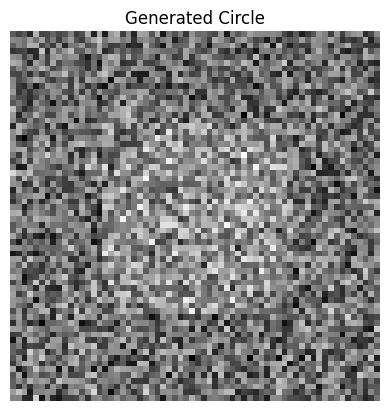

In [ ]:
noise = torch.randn(1, latent_dim)

label = torch.tensor([0])

fake_img = generator(
    noise,
    label
).detach().numpy()[0,0]

plt.imshow(fake_img, cmap="gray")

plt.title("Generated Circle")

plt.axis("off")

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

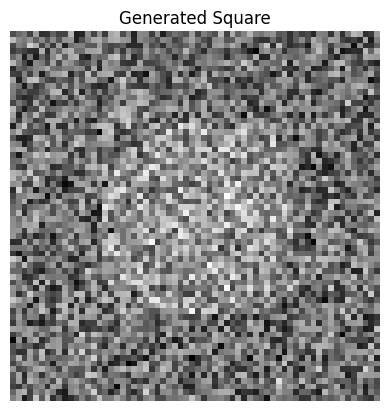

In [ ]:
noise = torch.randn(1, latent_dim)

label = torch.tensor([1])

fake_img = generator(
    noise,
    label
).detach().numpy()[0,0]

plt.imshow(fake_img, cmap="gray")

plt.title("Generated Square")

plt.axis("off")